<a href="https://colab.research.google.com/github/anuragkumar8947-create/Credit_Card_Fraud_Detection/blob/main/Credit_Card_Fraud_Detection_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PROBLEM STATEMENT:

A credit card is widely used for transaction but with increasing usage fraudlent transactions have also increased.
The goal is to build a machine learning model that can
detect whether a transaction is fraud or geniune.

# Why this important:
1. prevent financial loss
2. improve transaction security
3. Automation the fraud detection

# IMPORT LIBRARIES

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# LOAD THE DATASET:

Dataset Link : https://drive.google.com/file/d/1XxtdBii1NFfPJwPFgVRz07BvOsfGxEK9/view?usp=drive_link

In [ ]:
df=pd.read_csv('/content/creditcard.csv.crdownload')

In [ ]:
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11660,19915,1.294875,-0.645847,0.689549,-0.351634,-1.026884,-0.129811,-0.928101,0.114172,0.804717,...,-0.097462,-0.020893,0.040297,0.159282,0.350705,-0.278351,-0.010354,-0.008003,10.00,0.0
11661,19915,1.404683,-0.554883,0.612239,-0.234956,-1.190992,-0.816824,-0.775771,-0.142637,1.121638,...,-0.196110,-0.303562,0.005661,0.313352,0.473813,-0.276618,-0.024026,0.002106,5.00,0.0
11662,19915,-0.945541,0.479754,1.521916,-1.298658,-0.852548,-0.604029,-0.354686,0.498106,0.407159,...,-0.050745,0.056031,-0.055584,0.312195,0.026299,-0.413466,0.189152,0.086360,10.00,0.0
11663,19915,-0.087909,0.184093,1.683910,-0.837378,-0.682605,-0.669907,-0.056222,-0.120669,0.409636,...,-0.109428,-0.054760,-0.139329,0.333267,0.072695,-0.320292,0.006423,0.010148,10.00,0.0


# DATASET DESCRIPTION:

TIME: Time elapsed between transaction,

v1:v28: PCA Transformed features(For Privacy),

AMOUNT:Transaction Amount,

Class:Target variable(0=Geniune,1=fraud)

# EDA PART:


In [ ]:
df.head(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0
5,2,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0.0
6,4,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,...,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0.0
7,7,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,...,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0.0
8,7,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,...,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0.0
9,9,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,...,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0.0


In [ ]:
df.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
11660,19915,1.294875,-0.645847,0.689549,-0.351634,-1.026884,-0.129811,-0.928101,0.114172,0.804717,...,-0.097462,-0.020893,0.040297,0.159282,0.350705,-0.278351,-0.010354,-0.008003,10.0,0.0
11661,19915,1.404683,-0.554883,0.612239,-0.234956,-1.190992,-0.816824,-0.775771,-0.142637,1.121638,...,-0.196110,-0.303562,0.005661,0.313352,0.473813,-0.276618,-0.024026,0.002106,5.0,0.0
11662,19915,-0.945541,0.479754,1.521916,-1.298658,-0.852548,-0.604029,-0.354686,0.498106,0.407159,...,-0.050745,0.056031,-0.055584,0.312195,0.026299,-0.413466,0.189152,0.086360,10.0,0.0
11663,19915,-0.087909,0.184093,1.683910,-0.837378,-0.682605,-0.669907,-0.056222,-0.120669,0.409636,...,-0.109428,-0.054760,-0.139329,0.333267,0.072695,-0.320292,0.006423,0.010148,10.0,0.0
11664,19915,1.504229,-0.499337,0.052377,-0.576345,-0.393971,0.015149,-0.718603,-0.125852,1.023281,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11665 entries, 0 to 11664
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    11665 non-null  int64  
 1   V1      11665 non-null  float64
 2   V2      11665 non-null  float64
 3   V3      11665 non-null  float64
 4   V4      11665 non-null  float64
 5   V5      11665 non-null  float64
 6   V6      11665 non-null  float64
 7   V7      11665 non-null  float64
 8   V8      11665 non-null  float64
 9   V9      11665 non-null  float64
 10  V10     11665 non-null  float64
 11  V11     11665 non-null  float64
 12  V12     11664 non-null  float64
 13  V13     11664 non-null  float64
 14  V14     11664 non-null  float64
 15  V15     11664 non-null  float64
 16  V16     11664 non-null  float64
 17  V17     11664 non-null  float64
 18  V18     11664 non-null  float64
 19  V19     11664 non-null  float64
 20  V20     11664 non-null  float64
 21  V21     11664 non-null  float64
 22

In [ ]:
# MISSING VALUES ANALYSIS
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [ ]:
# COUNT NULL VALUES
df.isnull().sum().sum()

np.int64(19)

In [ ]:
18/39702*100  # Simply drop it if null values is in less amount.

0.04533776635937736

In [ ]:
# DROP
df.dropna(inplace=True)

In [ ]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [ ]:
df.duplicated().sum()            #--Check Duplicates Values.

np.int64(44)

In [ ]:
df[df.duplicated()].head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
33,26,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,...,0.046949,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0.0
35,26,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,...,0.049526,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0.0
113,74,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0.0
114,74,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0.0
115,74,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0.0


In [ ]:
df[df.duplicated(keep=False)].sort_values(by=list(df.columns))  ##-- IF we want to see the duplictes values in pair.

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
34,26,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,...,0.049526,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0.0
35,26,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,...,0.049526,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0.0
32,26,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,...,0.046949,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0.0
33,26,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,...,0.046949,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0.0
112,74,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9029,12587,-5.708411,4.794625,-1.155486,0.421606,-0.588195,1.152312,-1.428505,-6.065001,3.783663,...,5.441096,-0.955916,1.007934,0.045643,-1.318965,-0.915560,-5.045247,0.211421,1.00,0.0
11131,19266,1.091437,-0.227000,1.012208,1.632910,-0.300770,1.406175,-0.834692,0.479092,2.539540,...,-0.582540,-1.057564,-0.005109,-0.911855,0.435451,-0.509608,0.050319,0.001222,13.49,0.0
11132,19266,1.091437,-0.227000,1.012208,1.632910,-0.300770,1.406175,-0.834692,0.479092,2.539540,...,-0.582540,-1.057564,-0.005109,-0.911855,0.435451,-0.509608,0.050319,0.001222,13.49,0.0
11133,19266,1.101116,-0.211007,1.017825,1.628840,-0.295829,1.404372,-0.841340,0.480393,2.540130,...,-0.585575,-1.054920,-0.000694,-0.912112,0.437291,-0.509074,0.051265,0.000350,8.48,0.0


In [ ]:
df.drop_duplicates(inplace=True)         #--Drop duplicates values.

In [ ]:
## Check duplicates values.

df.duplicated().sum()

np.int64(0)

From the dataset, Calculate the number of genuine transactions, number of fraud transactions and the percentage of fraud transactions.

In [ ]:
fraud=df[df['Class']==1]
geniune=df[df['Class']==0]

In [ ]:
print('fraud Transaction:',len(fraud))
print('geniune Transaction:',len(geniune))

fraud Transaction: 49
geniune Transaction: 11571


In [ ]:
# If we want to see the percentage.

fraud_percentage=(len(fraud)/len(df))*100

In [ ]:
print('fraud_percentage',fraud_percentage)

fraud_percentage 0.42168674698795183


USING THE VISUALISATION MODULE, VISUALIZE THE GENUINE AND FRAUDULENT TRANSACTION USING A BAR GRAPH.

<function matplotlib.pyplot.show(close=None, block=None)>

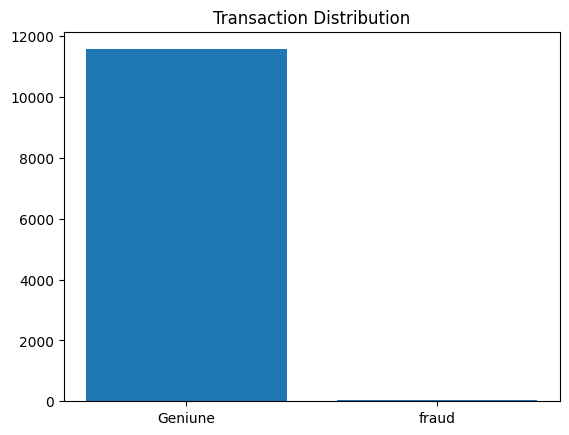

In [ ]:
counts=df['Class'].value_counts()

plt.bar(['Geniune','fraud'],counts)
plt.title('Transaction Distribution')
plt.show

USING THE STANDARD SCALER MODULE, NORMALIZE THE AMOUNT COLUMN AND STORE THE NEW VALUES IN THE NORMALIZED AMOUNT COLUMN.

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler=StandardScaler()

In [ ]:
df['NormalizedAmount']=scaler.fit_transform(df[['Amount']])

In [ ]:
df            #--SHOW THE DATASET

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,NormalizedAmount
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0,0.481127
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0,-0.334618
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0,1.752740
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0,0.336110
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0,0.039027
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11659,19914,1.348167,-0.531813,0.737667,-0.312410,-1.147767,-0.585711,-0.810412,-0.062116,0.705208,...,-0.076450,0.006995,0.489243,0.448523,-0.309831,-0.021411,-0.003987,5.00,0.0,-0.321793
11660,19915,1.294875,-0.645847,0.689549,-0.351634,-1.026884,-0.129811,-0.928101,0.114172,0.804717,...,-0.020893,0.040297,0.159282,0.350705,-0.278351,-0.010354,-0.008003,10.00,0.0,-0.294034
11661,19915,1.404683,-0.554883,0.612239,-0.234956,-1.190992,-0.816824,-0.775771,-0.142637,1.121638,...,-0.303562,0.005661,0.313352,0.473813,-0.276618,-0.024026,0.002106,5.00,0.0,-0.321793
11662,19915,-0.945541,0.479754,1.521916,-1.298658,-0.852548,-0.604029,-0.354686,0.498106,0.407159,...,0.056031,-0.055584,0.312195,0.026299,-0.413466,0.189152,0.086360,10.00,0.0,-0.294034


In [ ]:
# Then after we drop the previous Amount column, BCZ now we have normalized amount column.

df.drop(['Amount'],axis=1,inplace=True)

In [ ]:
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Class,NormalizedAmount
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.0,0.481127
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0.0,-0.334618
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0.0,1.752740
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.0,0.336110
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0.0,0.039027
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11659,19914,1.348167,-0.531813,0.737667,-0.312410,-1.147767,-0.585711,-0.810412,-0.062116,0.705208,...,-0.120215,-0.076450,0.006995,0.489243,0.448523,-0.309831,-0.021411,-0.003987,0.0,-0.321793
11660,19915,1.294875,-0.645847,0.689549,-0.351634,-1.026884,-0.129811,-0.928101,0.114172,0.804717,...,-0.097462,-0.020893,0.040297,0.159282,0.350705,-0.278351,-0.010354,-0.008003,0.0,-0.294034
11661,19915,1.404683,-0.554883,0.612239,-0.234956,-1.190992,-0.816824,-0.775771,-0.142637,1.121638,...,-0.196110,-0.303562,0.005661,0.313352,0.473813,-0.276618,-0.024026,0.002106,0.0,-0.321793
11662,19915,-0.945541,0.479754,1.521916,-1.298658,-0.852548,-0.604029,-0.354686,0.498106,0.407159,...,-0.050745,0.056031,-0.055584,0.312195,0.026299,-0.413466,0.189152,0.086360,0.0,-0.294034


# SPLIT THE DATASET INTO TRAINING AND TESTING

In [ ]:
pip install scikit-learn

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x = df.drop('Class',axis=1)
y=df['Class']

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)

# SMOTE TECHNIQUE
 Smote Stands For:
 Synthetic Minority Over-Sampling Technique,

 It is basically used for handle the imbalance data.

 #**Why do we need smote?**

 our dataset is highly imbalanced

 Geniune(Class=0)->73% , Fraud(Class=1)-26%

 #** PROBLEM

 Model Learns mostly geniune transaction

 ignore the fraud cases

 gives high accuracy but poor fraud detection.

 # What SMOTE Does?

 Smote Generates Synthetic Samples For the Minority class.

 # How Smote Works?

 1. picks a minority class point(fraud Case)

 2. Find its Nearest Neighbours.

 3. Creates a new point between them.

In [ ]:
!pip install imbalanced-learn

In [ ]:
from imblearn.over_sampling import SMOTE

In [ ]:
smote=SMOTE(random_state=42)

In [ ]:
x_train_smote,y_train_smote=smote.fit_resample(x_train,y_train)             #--Smote we use for only training data not testing data.

In [ ]:
print('Before SMOTE:',y_train.value_counts())                         #----- Here we balanced the data.
print('After SMOTE:',y_train_smote.value_counts())

Before SMOTE: Class
0.0    8104
1.0      30
Name: count, dtype: int64
After SMOTE: Class
0.0    8104
1.0    8104
Name: count, dtype: int64


## MODEL BUILDING

1. DECISION TREE

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
dt_model=DecisionTreeClassifier()

In [ ]:
dt_model.fit(x_train_smote,y_train_smote)            #-- Train the Model.

DecisionTreeClassifier()

In [ ]:
#--Test the Module.
dt_pred=dt_model.predict(x_test)

In [ ]:
dt_pred

array([0., 0., 0., ..., 0., 0., 1.])

In [ ]:
#--NOW, We check the accuracy of decision tree.
from sklearn.metrics import*

In [ ]:
 #--CHECKING THE ACCURACY.
accuracy_score(y_test,dt_pred)

0.9985656913367756

In [ ]:
#--CHECKING THE PRECISION.
precision_score(y_test,dt_pred)


0.9375

In [ ]:
#--CHECKING THE RECALL.
recall_score(y_test,dt_pred)

0.7894736842105263

In [ ]:
#--HERE WE DO ALL GET BY THE HELP OF CLASSIFICATION.
print(classification_report(y_test,dt_pred))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      3467
         1.0       0.94      0.79      0.86        19

    accuracy                           1.00      3486
   macro avg       0.97      0.89      0.93      3486
weighted avg       1.00      1.00      1.00      3486



## BUILD THE RANDOM FOREST MODEL FOR THIS DATA AND GIVE THE ACCURACY, PRECISION AND RECALL SCORE

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
#--BUILD RANDOM FOREST MODEL.
rf=RandomForestClassifier(n_estimators=100, random_state=42)

In [ ]:
#--TRAIN THE MODEL.
rf.fit(x_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
#--PREDICTION
y_pred = rf.predict(x_test)

In [ ]:
y_pred

array([0., 0., 0., ..., 0., 0., 1.])

In [ ]:
#--ACCURACY
accuracy = accuracy_score(y_test,y_pred)

In [ ]:
#--PRECISION
precision = precision_score(y_test,y_pred, average='weighted')

In [ ]:
#--RECALL
recall = recall_score(y_test,y_pred, average='weighted')

In [ ]:
#--PRINT RESULTS
print("Accuracy Score :", accuracy)
print("Precision score :", precision)
print("Recall score :", recall)

Accuracy Score : 1.0
Precision score : 1.0
Recall score : 1.0
